## Technical Indicators

### Moving Averages (MA)
- **MA10:** Average price of the last 10 days.
- **MA30:** Average price of the last 30 days.

### Volatility
Measures price variability.
- **Formula:** Standard deviation of the last 10 prices.
- **Interpretation:** High volatility → unstable market.

### Momentum
Measures price strength and direction.

**Example:**

| Price Today | Price 10 Days Ago | Momentum |
| :--- | :--- | :--- |
| 70000 | 65000 | +5000 |

*Note:* Positive momentum means uptrend strength.

### Bollinger Bands
Identifies potential overbought or oversold conditions based on price action relative to dynamic bands.

**If price hits:**

| Position | Meaning |
| :--- | :--- |
| Upper band | Overbought |
| Lower band | Oversold |

### Moving Average Convergence Divergence (MACD)
Measures trend momentum to identify the strength and direction of a price trend.

- **Mechanism:** Compares a Short-term EMA vs. a Long-term EMA.
- **Interpretation:** If MACD > 0 → bullish momentum.

[*********************100%***********************]  1 of 1 completed

                  Price       Volume
Date                                
2020-01-01  7200.174316  18565664997
2020-01-02  6985.470215  20802083465
2020-01-03  7344.884277  28111481032
2020-01-04  7410.656738  18444271275
2020-01-05  7411.317383  19725074095


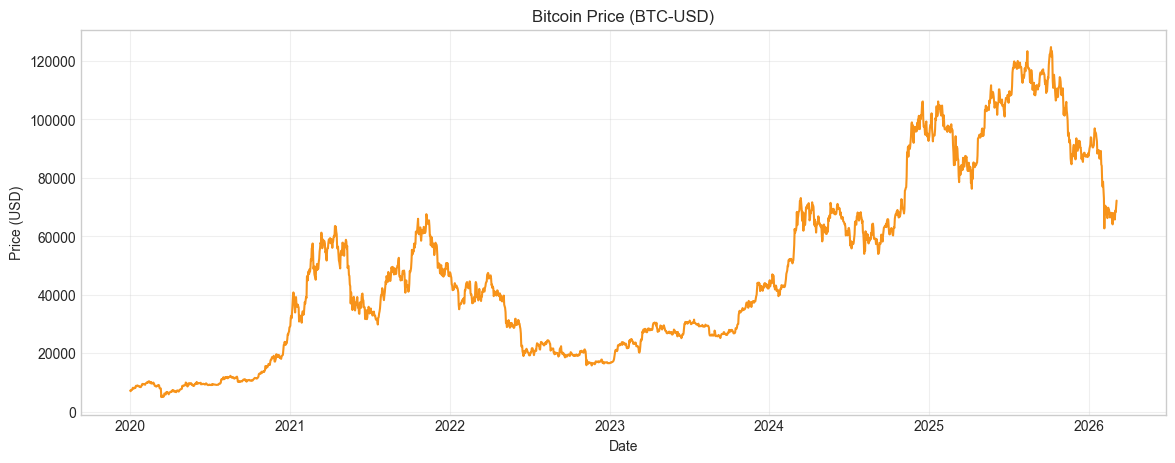

MAE: 7257.885270130952
RMSE: 9101.554249949453


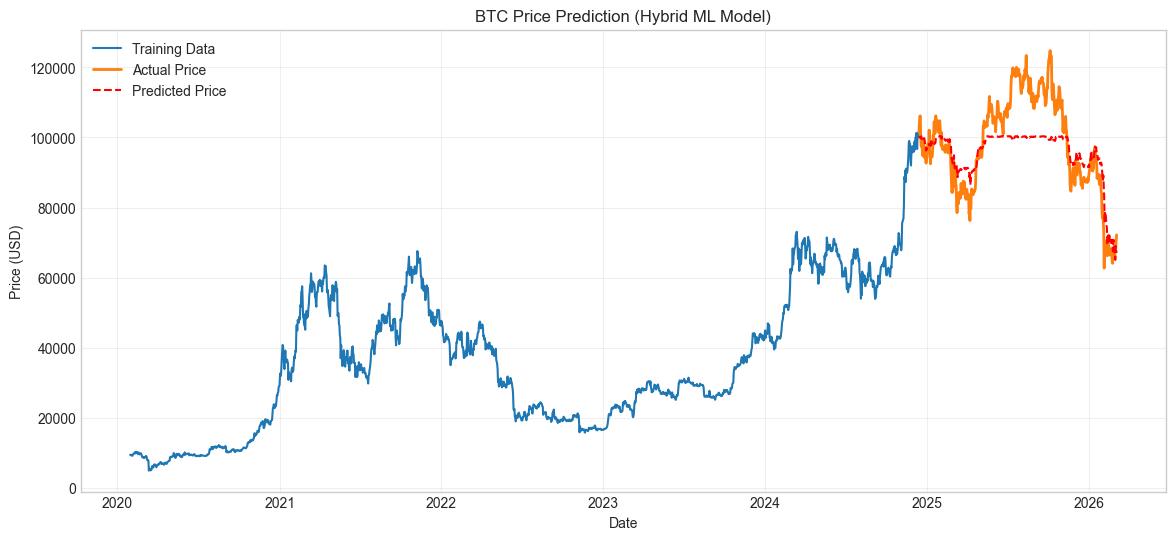

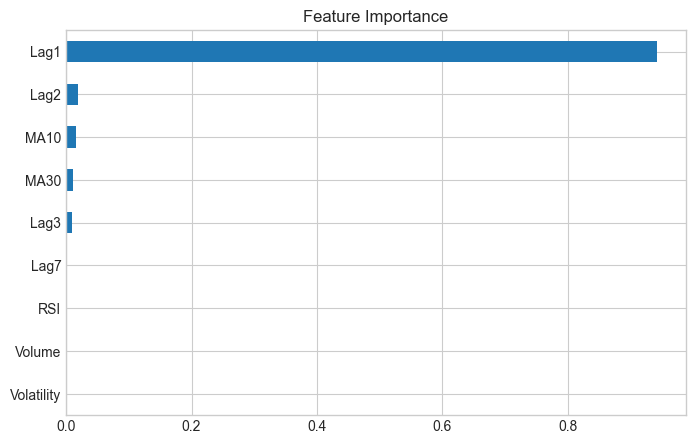

In [164]:
# =====================================
# 1. Install Required Libraries
# =====================================

# !pip install --quiet yfinance scikit-learn matplotlib pandas numpy

# =====================================
# 2. Import Libraries
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================
# 3. Download BTC Data
# =====================================

btc = yf.download("BTC-USD", start="2020-01-01")

data = pd.DataFrame()
data["Price"] = btc["Close"].squeeze()
data["Volume"] = btc["Volume"].squeeze()

print(data.head())

# =====================================
# 4. Plot BTC Price
# =====================================

plt.figure(figsize=(14,5))

plt.plot(data.index, data["Price"], color="#F7931A")

plt.title("Bitcoin Price (BTC-USD)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)

plt.show()

# =====================================
# 5. Create Technical Indicators
# =====================================

# Moving averages
data["MA10"] = data["Price"].rolling(10).mean()
data["MA30"] = data["Price"].rolling(30).mean()

# RSI (simple implementation)
delta = data["Price"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data["RSI"] = 100 - (100 / (1 + rs))

# Volatility
data["Volatility"] = data["Price"].rolling(10).std()

# =====================================
# 6. Create Lag Features
# =====================================

data["Lag1"] = data["Price"].shift(1)
data["Lag2"] = data["Price"].shift(2)
data["Lag3"] = data["Price"].shift(3)
data["Lag7"] = data["Price"].shift(7)

# =====================================
# 7. Remove Missing Values
# =====================================

data = data.dropna()

# =====================================
# 8. Define Features and Target
# =====================================

features = [
    "MA10",
    "MA30",
    "RSI",
    "Volatility",
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag7",
    "Volume"
]

X = data[features]
y = data["Price"]

# =====================================
# 9. Train/Test Split (Time Series)
# =====================================

split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# =====================================
# 10. Train Random Forest Model
# =====================================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================
# 11. Predictions
# =====================================

predictions = model.predict(X_test)

predictions = pd.Series(predictions, index=y_test.index)

# =====================================
# 12. Model Evaluation
# =====================================

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

# =====================================
# 13. Plot Predictions
# =====================================

plt.figure(figsize=(14,6))

plt.plot(y_train, label="Training Data")

plt.plot(y_test, label="Actual Price", linewidth=2)

plt.plot(
    predictions,
    label="Predicted Price",
    linestyle="--",
    color="red"
)

plt.title("BTC Price Prediction (Hybrid ML Model)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# =====================================
# 14. Feature Importance
# =====================================

importances = pd.Series(model.feature_importances_, index=features)

importances.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[*********************100%***********************]  1 of 1 completed


MAE: 1983.5480934910715
RMSE: 2575.6015195538594


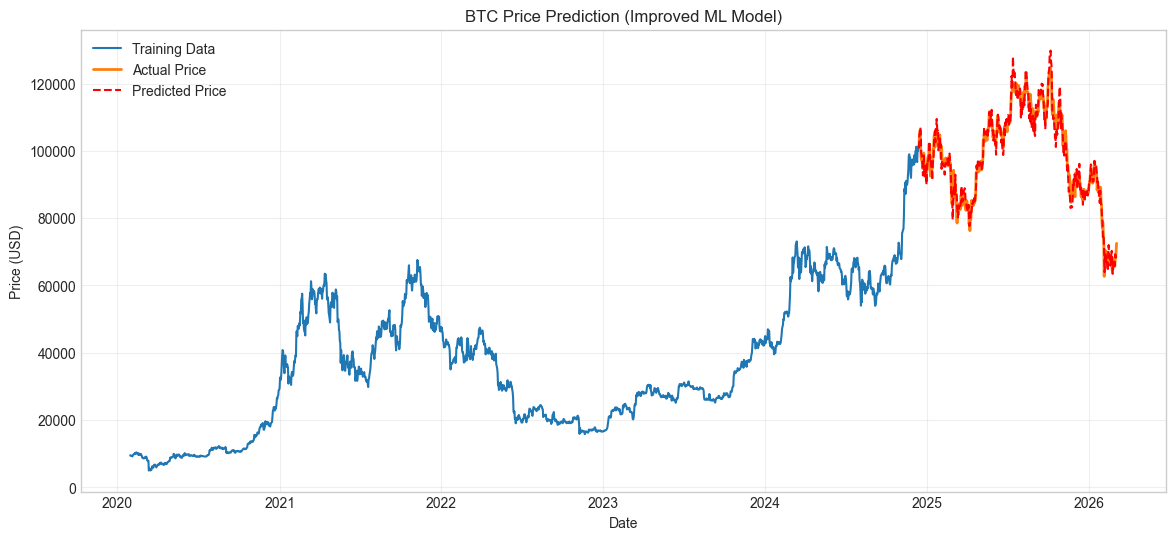

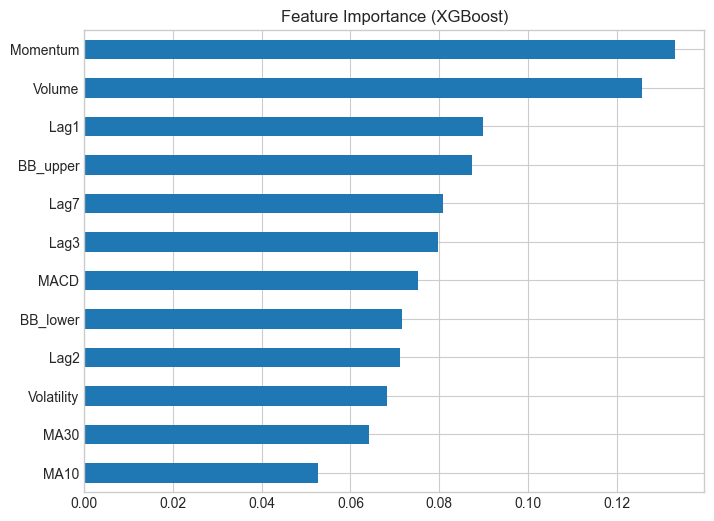

Direction Accuracy: 0.6053811659192825


In [165]:
# ============================================
# 1. Install Required Libraries
# ============================================

!pip install --quiet xgboost

# ============================================
# 2. Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================
# 3. Download BTC Data
# ============================================

btc = yf.download("BTC-USD", start="2020-01-01")

data = pd.DataFrame()
data["Price"] = btc["Close"].squeeze()
data["Volume"] = btc["Volume"].squeeze()

# ============================================
# 4. Create Target Variable (Returns)
# ============================================

data["Return"] = data["Price"].pct_change()

# Direction classification target
data["Direction"] = (data["Return"] > 0).astype(int)

# ============================================
# 5. Technical Indicators
# ============================================

# Moving averages
data["MA10"] = data["Price"].rolling(10).mean()
data["MA30"] = data["Price"].rolling(30).mean()

# Volatility
data["Volatility"] = data["Price"].rolling(10).std()

# Momentum
data["Momentum"] = data["Price"] - data["Price"].shift(10)

# Bollinger Bands
rolling_mean = data["Price"].rolling(20).mean()
rolling_std = data["Price"].rolling(20).std()

data["BB_upper"] = rolling_mean + 2 * rolling_std
data["BB_lower"] = rolling_mean - 2 * rolling_std

# MACD
ema12 = data["Price"].ewm(span=12, adjust=False).mean()
ema26 = data["Price"].ewm(span=26, adjust=False).mean()

data["MACD"] = ema12 - ema26

# ============================================
# 6. Lag Features
# ============================================

data["Lag1"] = data["Return"].shift(1)
data["Lag2"] = data["Return"].shift(2)
data["Lag3"] = data["Return"].shift(3)
data["Lag7"] = data["Return"].shift(7)

# ============================================
# 7. Drop Missing Values
# ============================================

data = data.dropna()

# ============================================
# 8. Feature Selection
# ============================================

features = [
    "MA10",
    "MA30",
    "Volatility",
    "Momentum",
    "BB_upper",
    "BB_lower",
    "MACD",
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag7",
    "Volume"
]

X = data[features]
y = data["Return"]

# ============================================
# 9. Train/Test Split (Time-Series Safe)
# ============================================

split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# ============================================
# 10. Train XGBoost Model
# ============================================

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

# ============================================
# 11. Predictions
# ============================================

pred_returns = model.predict(X_test)

pred_returns = pd.Series(pred_returns, index=y_test.index)

# Convert returns to predicted price

pred_price = data["Price"].shift(1).loc[pred_returns.index] * (1 + pred_returns)

# ============================================
# 12. Evaluation
# ============================================

actual_price = data["Price"].loc[pred_price.index]

mae = mean_absolute_error(actual_price, pred_price)
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))

print("MAE:", mae)
print("RMSE:", rmse)

# ============================================
# 13. Plot Predictions
# ============================================

plt.figure(figsize=(14,6))

plt.plot(data["Price"][:split], label="Training Data")

plt.plot(actual_price, label="Actual Price", linewidth=2)

plt.plot(pred_price, label="Predicted Price", linestyle="--", color="red")

plt.title("BTC Price Prediction (Improved ML Model)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ============================================
# 14. Feature Importance
# ============================================

importances = pd.Series(model.feature_importances_, index=features)

importances.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance (XGBoost)")

plt.show()

# ============================================
# 15. Direction Accuracy
# ============================================

pred_direction = (pred_returns > 0).astype(int)

actual_direction = (y_test > 0).astype(int)

accuracy = (pred_direction == actual_direction).mean()

print("Direction Accuracy:", accuracy)

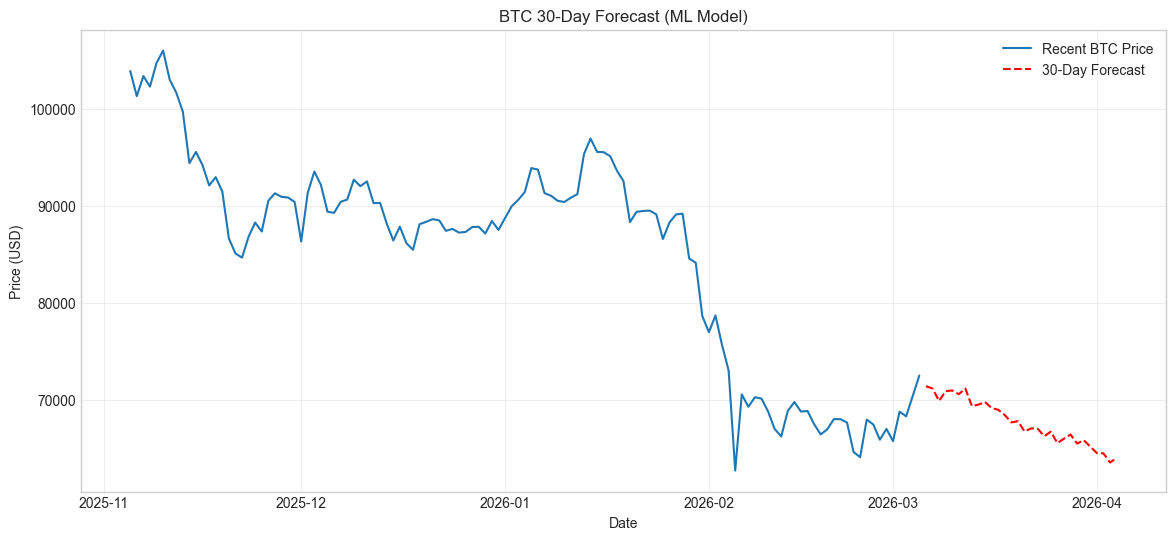

In [167]:
plt.figure(figsize=(14,6))

plt.plot(data["Price"].tail(120), label="Recent BTC Price")

plt.plot(future_prices, label="30-Day Forecast", linestyle="--", color="red")

plt.title("BTC 30-Day Forecast (ML Model)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

## HOURLY DATA

In [ ]:
# ============================================
# 1. Install Required Libraries
# ============================================

# !pip install --quiet xgboost yfinance

# ============================================
# 2. Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8")

In [ ]:
# ============================================
# 3. Download BTC Hourly Data
# ============================================

# Yahoo allows ~730 days for hourly data

btc = yf.download(
    "BTC-USD",
    period="730d",
    interval="1h"
)

data = pd.DataFrame()
data["Price"] = btc["Close"]
data["Volume"] = btc["Volume"]

In [ ]:
# ============================================
# 4. Create Target Variable
# ============================================

data["Return"] = data["Price"].pct_change()

data["Direction"] = (data["Return"] > 0).astype(int)

In [ ]:
# ============================================
# 5. Technical Indicators (Adjusted for Hourly)
# ============================================

# Moving averages (shorter windows)

data["MA12"] = data["Price"].rolling(12).mean()   # ~half day
data["MA48"] = data["Price"].rolling(48).mean()   # ~2 days

# Volatility

data["Volatility"] = data["Price"].rolling(24).std()

# Momentum

data["Momentum"] = data["Price"] - data["Price"].shift(12)

# Bollinger Bands

rolling_mean = data["Price"].rolling(24).mean()
rolling_std = data["Price"].rolling(24).std()

data["BB_upper"] = rolling_mean + 2 * rolling_std
data["BB_lower"] = rolling_mean - 2 * rolling_std

# MACD

ema12 = data["Price"].ewm(span=12, adjust=False).mean()
ema26 = data["Price"].ewm(span=26, adjust=False).mean()

data["MACD"] = ema12 - ema26

In [ ]:
# ============================================
# 6. Lag Features (Hourly)
# ============================================

data["Lag1"] = data["Return"].shift(1)
data["Lag2"] = data["Return"].shift(2)
data["Lag3"] = data["Return"].shift(3)
data["Lag6"] = data["Return"].shift(6)
data["Lag12"] = data["Return"].shift(12)



In [ ]:
# ============================================
# 7. Drop Missing Values
# ============================================
data = data.dropna()

In [ ]:
# ============================================
# 8. Feature Selection
# ============================================

features = [
    "MA12",
    "MA48",
    "Volatility",
    "Momentum",
    "BB_upper",
    "BB_lower",
    "MACD",
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag6",
    "Lag12",
    "Volume"
]

X = data[features]
y = data["Return"]

In [ ]:
# ============================================
# 9. Train/Test Split (Time-Series Safe)
# ============================================

split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
# ============================================
# 10. Train XGBoost Model
# ============================================

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
# ============================================
# 11. Predictions
# ============================================

pred_returns = model.predict(X_test)

pred_returns = pd.Series(pred_returns, index=y_test.index)

pred_price = data["Price"].shift(1).loc[pred_returns.index] * (1 + pred_returns)

In [ ]:
# ============================================
# 12. Evaluation
# ============================================

actual_price = data["Price"].loc[pred_price.index]

mae = mean_absolute_error(actual_price, pred_price)
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))

print("MAE:", mae)
print("RMSE:", rmse)

In [ ]:
# ============================================
# 13. Plot Predictions
# ============================================

plt.figure(figsize=(14,6))

plt.plot(data["Price"][:split], label="Training Data")

plt.plot(actual_price, label="Actual Price", linewidth=2)

plt.plot(pred_price, label="Predicted Price", linestyle="--", color="red")

plt.title("BTC Hourly Price Prediction (XGBoost)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================
# 14. Feature Importance
# ============================================

importances = pd.Series(model.feature_importances_, index=features)

importances.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance (XGBoost)")

plt.show()

In [ ]:
# ============================================
# 15. Direction Accuracy
# ============================================

pred_direction = (pred_returns > 0).astype(int)

actual_direction = (y_test > 0).astype(int)

accuracy = (pred_direction == actual_direction).mean()

print("Direction Accuracy:", accuracy)

In [ ]:
# ============================================
# 16. Future Forecast (Next 24 Hours)
# ============================================

future_steps = 24
last_features = X.iloc[-1:].copy()

future_prices = []

last_price = data["Price"].iloc[-1]

for i in range(future_steps):

    pred_return = model.predict(last_features)[0]

    next_price = last_price * (1 + pred_return)

    future_prices.append(next_price)

    last_price = next_price

future_index = pd.date_range(
    start=data.index[-1],
    periods=future_steps+1,
    freq="H"
)[1:]

future_prices = pd.Series(future_prices, index=future_index)

[*********************100%***********************]  1 of 1 completed


MAE: 283.3665258591329
RMSE: 403.47783928947064


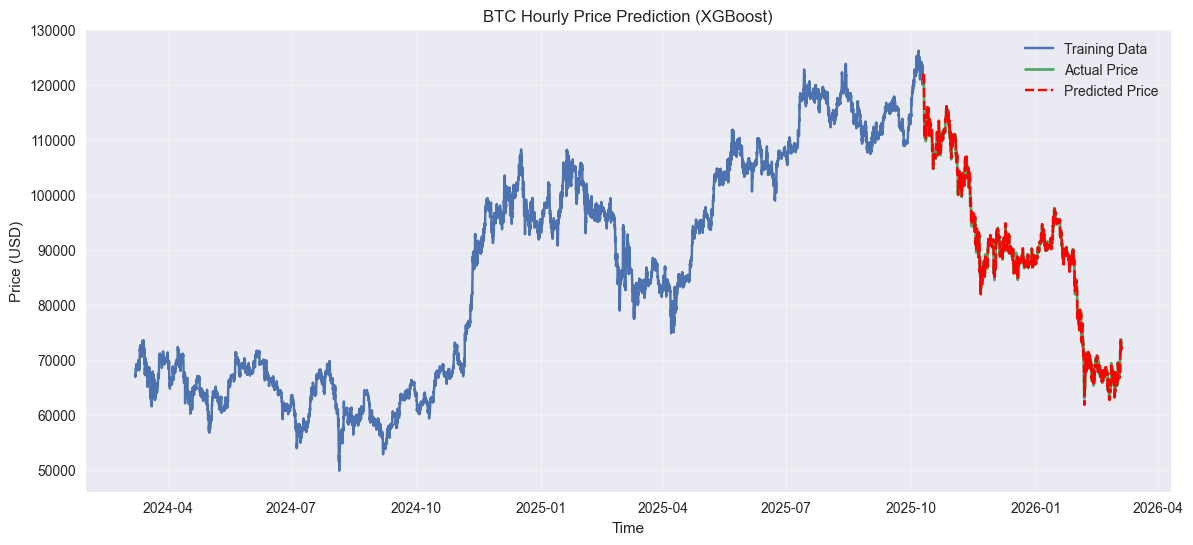

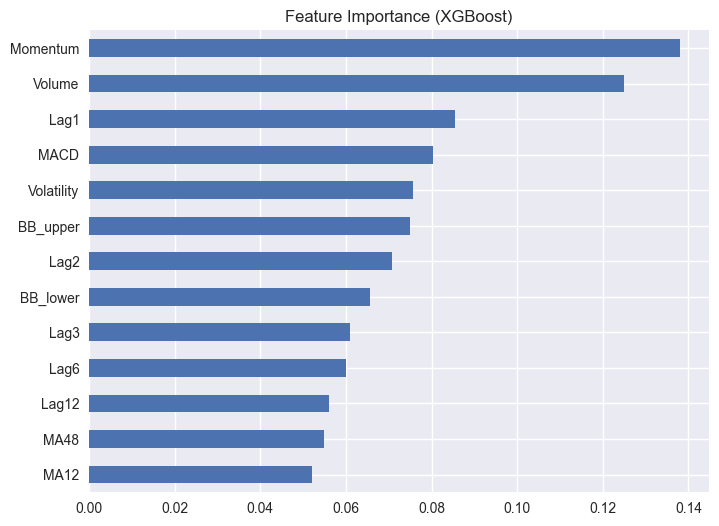

Direction Accuracy: 0.6157819225251076


C:\Users\Hexi\AppData\Local\Temp\ipykernel_11392\2413505963.py:233: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


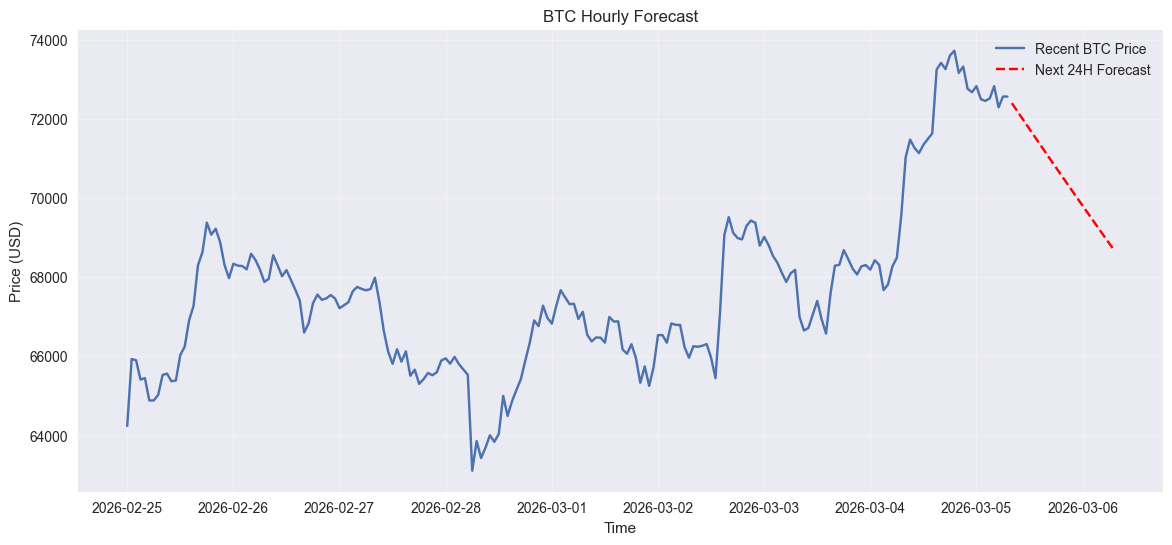

In [1]:
# ============================================
# 17. Plot Future Forecast
# ============================================

plt.figure(figsize=(14,6))

plt.plot(data["Price"].tail(200), label="Recent BTC Price")

plt.plot(future_prices, label="Next 24H Forecast", linestyle="--", color="red")

plt.title("BTC Hourly Forecast")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [2]:
future_prices

2026-03-05 08:00:00+00:00    72394.095448
2026-03-05 09:00:00+00:00    72229.270148
2026-03-05 10:00:00+00:00    72064.820119
2026-03-05 11:00:00+00:00    71900.744506
2026-03-05 12:00:00+00:00    71737.042457
2026-03-05 13:00:00+00:00    71573.713121
2026-03-05 14:00:00+00:00    71410.755650
2026-03-05 15:00:00+00:00    71248.169197
2026-03-05 16:00:00+00:00    71085.952917
2026-03-05 17:00:00+00:00    70924.105967
2026-03-05 18:00:00+00:00    70762.627507
2026-03-05 19:00:00+00:00    70601.516698
2026-03-05 20:00:00+00:00    70440.772703
2026-03-05 21:00:00+00:00    70280.394685
2026-03-05 22:00:00+00:00    70120.381813
2026-03-05 23:00:00+00:00    69960.733255
2026-03-06 00:00:00+00:00    69801.448181
2026-03-06 01:00:00+00:00    69642.525764
2026-03-06 02:00:00+00:00    69483.965179
2026-03-06 03:00:00+00:00    69325.765600
2026-03-06 04:00:00+00:00    69167.926207
2026-03-06 05:00:00+00:00    69010.446179
2026-03-06 06:00:00+00:00    68853.324698
2026-03-06 07:00:00+00:00    68696

[*********************100%***********************]  1 of 1 completed


Price              Price       Volume          MA10          MA30  \
Date                                                                
2018-01-30  10106.299805   8637859840  11181.980176  13181.040039   
2018-01-31  10221.099609   8041160192  11044.080176  13066.503353   
2018-02-01   9170.540039   9959400448  10867.994141  12872.784701   
2018-02-02   8830.750000  12726899712  10664.229102  12660.443034   
2018-02-03   9174.910156   7263790080  10445.780078  12446.300033   

Price        Volatility     Momentum  
Date                                  
2018-01-30   468.549610 -2792.900391  
2018-01-31   530.634017 -1379.000000  
2018-02-01   797.325051 -1760.860352  
2018-02-02  1025.058629 -2037.650391  
2018-02-03  1091.090931 -2184.490234  
Scaled data shape: (2957, 6)
X shape: (2897, 60, 6)
y shape: (2897,)


C:\Users\Hexi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,313 (208.25 KB)

 Trainable params: 53,313 (208.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0031 - val_loss: 0.0063
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0011 - val_loss: 0.0079
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 8.6985e-04 - val_loss: 0.0050
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 7.3024e-04 - val_loss: 0.0016
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 6.4455e-04 - val_loss: 0.0038
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 6.9193e-04 - val_loss: 0.0020
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 5.8710e-04 - val_loss: 0.0042
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.3337e-04 - val_loss: 0.0070
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.0761e-04 - val_loss: 8.6067e-04
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 5.1796e-04 - val_loss: 0.0011
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 4.7190e-04 - val_loss: 0.0038
Epoch 12/50
73/73 ━━━━━

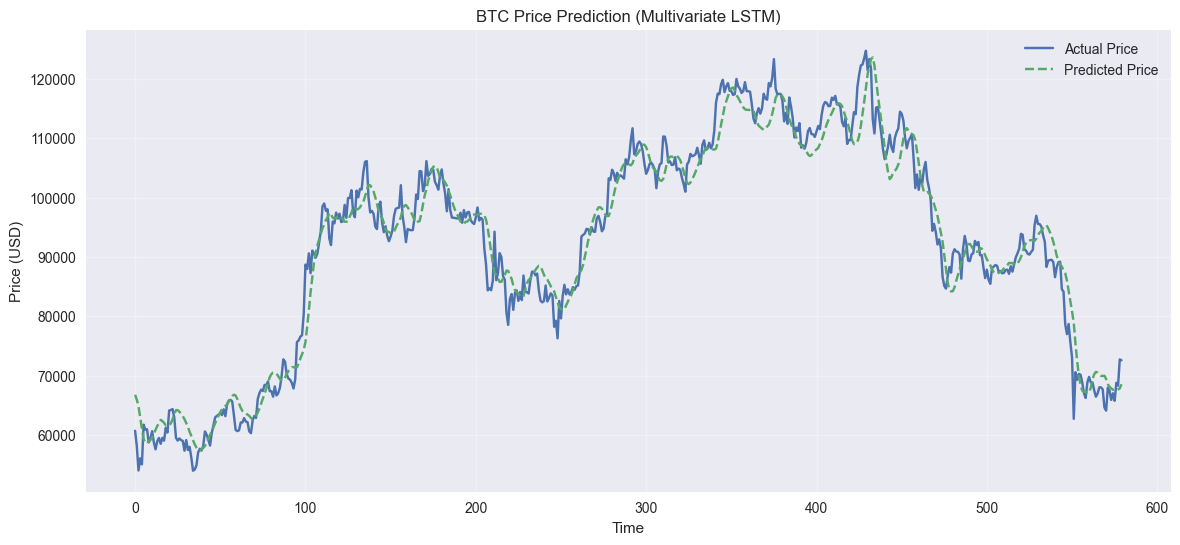

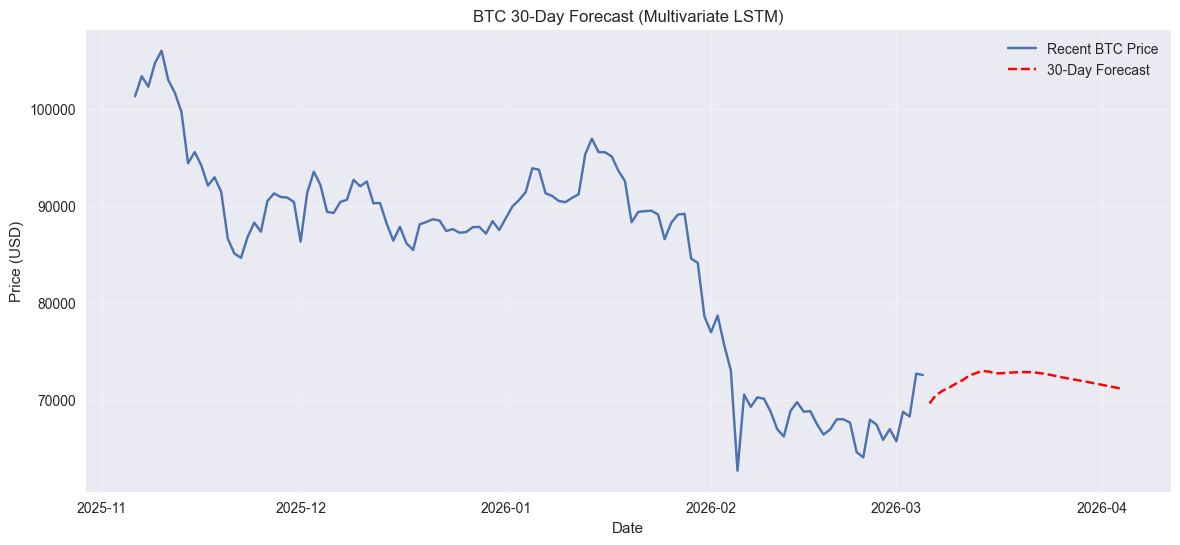

In [3]:
# ===============================
# 1. Import Libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ===============================
# 2. Download BTC Data
# ===============================

btc = yf.download("BTC-USD", start="2018-01-01")

btc.columns = btc.columns.droplevel(1)

data = btc[['Close','Volume']].copy()

data.rename(columns={"Close":"Price"}, inplace=True)
# ===============================
# 3. Feature Engineering
# ===============================

data["MA10"] = data["Price"].rolling(10).mean()
data["MA30"] = data["Price"].rolling(30).mean()

data["Volatility"] = data["Price"].rolling(10).std()

data["Momentum"] = data["Price"] - data["Price"].shift(10)

data = data.dropna()

print(data.head())


# ===============================
# 4. Scale Data
# ===============================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)


# ===============================
# 5. Create Sequences
# ===============================

sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i,0])  # price column

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ===============================
# 6. Train Test Split
# ===============================

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# ===============================
# 7. Build LSTM Model
# ===============================

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()


# ===============================
# 8. Train Model
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


# ===============================
# 9. Predict Test Data
# ===============================

predictions = model.predict(X_test)


# ===============================
# 10. Inverse Scaling
# ===============================

pred_dummy = np.zeros((len(predictions), scaled_data.shape[1]))
pred_dummy[:,0] = predictions.flatten()

predictions = scaler.inverse_transform(pred_dummy)[:,0]


y_dummy = np.zeros((len(y_test), scaled_data.shape[1]))
y_dummy[:,0] = y_test

y_test_actual = scaler.inverse_transform(y_dummy)[:,0]


# ===============================
# 11. Evaluate Model
# ===============================

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("MAE:", mae)
print("RMSE:", rmse)


# ===============================
# 12. Plot Predictions
# ===============================

plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price", linestyle="--")

plt.title("BTC Price Prediction (Multivariate LSTM)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ===============================
# 13. Forecast Next 30 Days
# ===============================

future_days = 30
future_prices = []

temp_data = data.copy()

for _ in range(future_days):

    scaled_temp = scaler.transform(temp_data.iloc[-sequence_length:])

    current_sequence = scaled_temp.reshape(
        1,
        sequence_length,
        scaled_data.shape[1]
    )

    pred_scaled = model.predict(current_sequence, verbose=0)[0][0]

    dummy = np.zeros((1, scaled_data.shape[1]))
    dummy[0,0] = pred_scaled

    pred_price = scaler.inverse_transform(dummy)[0,0]

    future_prices.append(pred_price)

    new_row = temp_data.iloc[-1].copy()
    new_row["Price"] = pred_price

    temp_data = pd.concat(
        [temp_data, pd.DataFrame([new_row])],
        ignore_index=True
    )

    temp_data["MA10"] = temp_data["Price"].rolling(10).mean()
    temp_data["MA30"] = temp_data["Price"].rolling(30).mean()
    temp_data["Volatility"] = temp_data["Price"].rolling(10).std()
    temp_data["Momentum"] = temp_data["Price"] - temp_data["Price"].shift(10)

    temp_data = temp_data.bfill()


# ===============================
# 14. Create Forecast Dates
# ===============================

future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

future_prices = pd.Series(
    future_prices,
    index=future_dates
)


# ===============================
# 15. Plot Forecast
# ===============================

plt.figure(figsize=(14,6))

plt.plot(
    data["Price"].tail(120),
    label="Recent BTC Price"
)

plt.plot(
    future_prices,
    label="30-Day Forecast",
    linestyle="--",
    color="red"
)

plt.title("BTC 30-Day Forecast (Multivariate LSTM)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

[*********************100%***********************]  1 of 1 completed


Price                             Price  Volume
Datetime                                       
2024-03-06 00:00:00+00:00  63519.824219       0
2024-03-06 01:00:00+00:00  63165.554688       0
2024-03-06 02:00:00+00:00  62908.753906       0
2024-03-06 03:00:00+00:00  63346.152344       0
2024-03-06 04:00:00+00:00  64508.902344       0
(17328, 6)
Scaled shape: (17328, 6)
X shape: (17256, 72, 6)
y shape: (17256,)


C:\Users\Hexi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 72, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 72, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,313 (208.25 KB)

 Trainable params: 53,313 (208.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0054 - val_loss: 4.9556e-04
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 0.0015 - val_loss: 3.6940e-04
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 0.0011 - val_loss: 3.0697e-04
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 8.8953e-04 - val_loss: 2.3402e-04
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 7.2411e-04 - val_loss: 1.9051e-04
Epoch 6/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - loss: 6.0609e-04 - val_loss: 3.3927e-04
Epoch 7/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 5.7426e-04 - val_loss: 3.4127e-04
Epoch 8/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 5.2527e-04 - val_loss: 1.8269e-04
Epoch 9/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 5.0987e-04 - val_loss: 1.5503e-04
Epoch 10/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 4.6618e-04 - val_loss: 1.5538e-04
Epoch 11/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/s

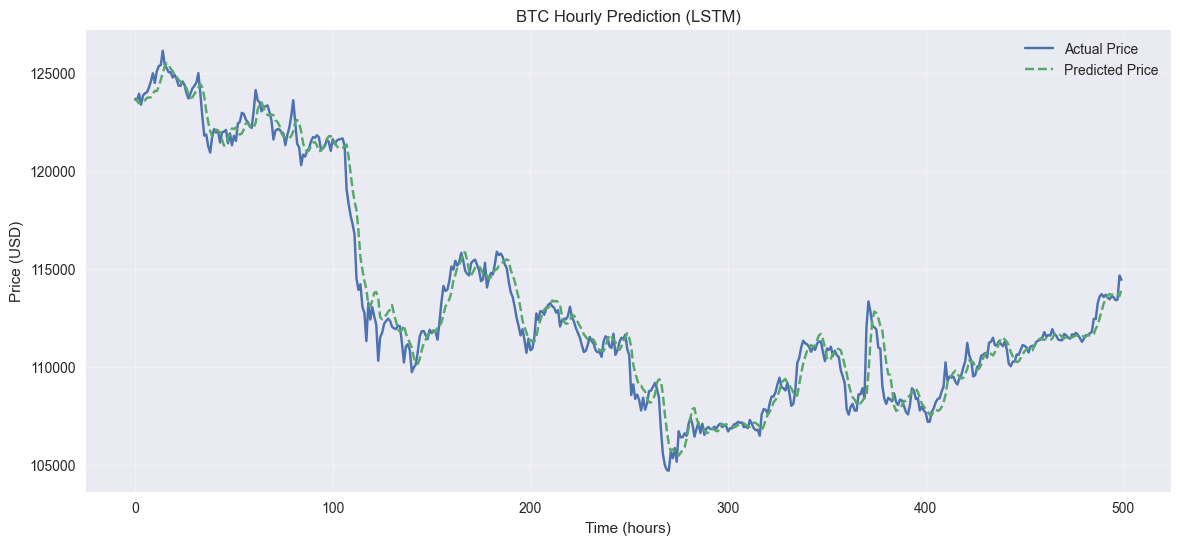

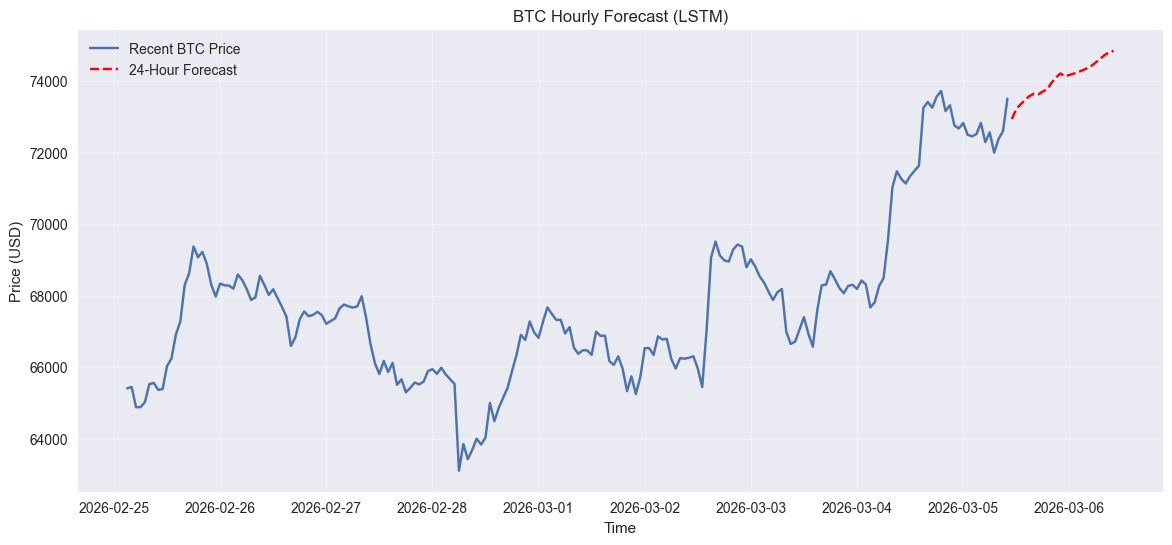

In [5]:
# ===============================
# 1. Import Libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ===============================
# 2. Download Hourly BTC Data
# ===============================

btc = yf.download(
    "BTC-USD",
    period="730d",
    interval="1h"
)

btc.columns = btc.columns.droplevel(1)

data = btc[['Close','Volume']].copy()

data.rename(columns={"Close":"Price"}, inplace=True)

print(data.head())


# ===============================
# 3. Feature Engineering (Hourly)
# ===============================

# 12 hours moving average
data["MA12"] = data["Price"].rolling(12).mean()

# 24 hours moving average
data["MA24"] = data["Price"].rolling(24).mean()

# hourly volatility
data["Volatility"] = data["Price"].rolling(12).std()

# hourly momentum
data["Momentum"] = data["Price"] - data["Price"].shift(12)

data = data.dropna()

print(data.shape)


# ===============================
# 4. Scale Data
# ===============================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Scaled shape:", scaled_data.shape)


# ===============================
# 5. Create Sequences
# ===============================

# 72 hours history (3 days)
sequence_length = 72

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ===============================
# 6. Train Test Split
# ===============================

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# ===============================
# 7. Build LSTM Model
# ===============================

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()


# ===============================
# 8. Train Model
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


# ===============================
# 9. Predict Test Data
# ===============================

predictions = model.predict(X_test)


# ===============================
# 10. Inverse Scaling
# ===============================

pred_dummy = np.zeros((len(predictions), scaled_data.shape[1]))
pred_dummy[:,0] = predictions.flatten()

predictions = scaler.inverse_transform(pred_dummy)[:,0]


y_dummy = np.zeros((len(y_test), scaled_data.shape[1]))
y_dummy[:,0] = y_test

y_test_actual = scaler.inverse_transform(y_dummy)[:,0]


# ===============================
# 11. Evaluation
# ===============================

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("MAE:", mae)
print("RMSE:", rmse)


# ===============================
# 12. Plot Predictions
# ===============================

plt.figure(figsize=(14,6))

plt.plot(y_test_actual[:500], label="Actual Price")
plt.plot(predictions[:500], label="Predicted Price", linestyle="--")

plt.title("BTC Hourly Prediction (LSTM)")
plt.xlabel("Time (hours)")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()


# ===============================
# 13. Forecast Next 24 Hours
# ===============================

future_hours = 24
future_prices = []

temp_data = data.copy()

for _ in range(future_hours):

    scaled_temp = scaler.transform(temp_data.iloc[-sequence_length:])

    current_sequence = scaled_temp.reshape(
        1,
        sequence_length,
        scaled_data.shape[1]
    )

    pred_scaled = model.predict(current_sequence, verbose=0)[0][0]

    dummy = np.zeros((1, scaled_data.shape[1]))
    dummy[0,0] = pred_scaled

    pred_price = scaler.inverse_transform(dummy)[0,0]

    future_prices.append(pred_price)

    new_row = temp_data.iloc[-1].copy()
    new_row["Price"] = pred_price

    temp_data = pd.concat(
        [temp_data, pd.DataFrame([new_row])],
        ignore_index=True
    )

    temp_data["MA12"] = temp_data["Price"].rolling(12).mean()
    temp_data["MA24"] = temp_data["Price"].rolling(24).mean()
    temp_data["Volatility"] = temp_data["Price"].rolling(12).std()
    temp_data["Momentum"] = temp_data["Price"] - temp_data["Price"].shift(12)

    temp_data = temp_data.bfill()


# ===============================
# 14. Create Hourly Dates
# ===============================

future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(hours=1),
    periods=future_hours,
    freq="h"
)

future_prices = pd.Series(
    future_prices,
    index=future_dates
)


# ===============================
# 15. Plot Hourly Forecast
# ===============================

plt.figure(figsize=(14,6))

plt.plot(
    data["Price"].tail(200),
    label="Recent BTC Price"
)

plt.plot(
    future_prices,
    label="24-Hour Forecast",
    linestyle="--",
    color="red"
)

plt.title("BTC Hourly Forecast (LSTM)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [6]:
future_prices

2026-03-05 11:00:00+00:00    72934.778036
2026-03-05 12:00:00+00:00    73213.322512
2026-03-05 13:00:00+00:00    73345.978224
2026-03-05 14:00:00+00:00    73472.325552
2026-03-05 15:00:00+00:00    73576.195568
2026-03-05 16:00:00+00:00    73641.019099
2026-03-05 17:00:00+00:00    73621.834700
2026-03-05 18:00:00+00:00    73704.032439
2026-03-05 19:00:00+00:00    73761.501495
2026-03-05 20:00:00+00:00    73950.791666
2026-03-05 21:00:00+00:00    74101.099026
2026-03-05 22:00:00+00:00    74207.159011
2026-03-05 23:00:00+00:00    74128.204154
2026-03-06 00:00:00+00:00    74163.061726
2026-03-06 01:00:00+00:00    74202.567581
2026-03-06 02:00:00+00:00    74246.983241
2026-03-06 03:00:00+00:00    74295.978961
2026-03-06 04:00:00+00:00    74351.774272
2026-03-06 05:00:00+00:00    74420.368280
2026-03-06 06:00:00+00:00    74517.113506
2026-03-06 07:00:00+00:00    74619.393919
2026-03-06 08:00:00+00:00    74722.984219
2026-03-06 09:00:00+00:00    74796.679057
2026-03-06 10:00:00+00:00    74842